# Online Learning & Incremental Models

> **Key idea**: Learn from one sample at a time, update the model instantly, never store the full dataset.

Batch learning assumes you have all data upfront. Online learning assumes data arrives as a stream — one example at a time — and the model must update with each new example without revisiting past data.

**When batch learning breaks down:**
- Dataset is too large to fit in RAM (IoT sensors, clickstreams, financial ticks)
- Data distribution changes over time (**concept drift**)
- Predictions are needed before enough data accumulates
- Privacy constraints prevent storing historical data

---

## The Online Learning Framework

At each round $t = 1, 2, \ldots, T$:
1. Receive feature vector $\mathbf{x}_t \in \mathbb{R}^d$
2. Predict $\hat{y}_t = f_t(\mathbf{x}_t)$
3. Observe true label $y_t$
4. Suffer loss $\ell(\hat{y}_t, y_t)$
5. **Update model** $f_t \rightarrow f_{t+1}$

**Regret** measures how much worse we do compared to the best fixed model in hindsight:

$$\text{Regret}_T = \sum_{t=1}^{T} \ell(f_t(\mathbf{x}_t), y_t) - \min_{f^* \in \mathcal{F}} \sum_{t=1}^{T} \ell(f^*(\mathbf{x}_t), y_t)$$

A **no-regret** algorithm achieves $\text{Regret}_T / T \rightarrow 0$ as $T \rightarrow \infty$. SGD achieves $O(\sqrt{T})$ regret.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Libraries loaded')

Libraries loaded


---
## 1. Online SGD — From Scratch

Standard gradient descent computes gradients over the **full batch**:
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}} \frac{1}{n} \sum_{i=1}^{n} \ell(\mathbf{w}; \mathbf{x}_i, y_i)$$

Online SGD updates on **a single example** at time $t$:
$$\mathbf{w}_{t+1} \leftarrow \mathbf{w}_t - \eta_t \nabla_{\mathbf{w}} \ell(\mathbf{w}_t; \mathbf{x}_t, y_t)$$

For squared loss $\ell = (\mathbf{w}^\top \mathbf{x}_t - y_t)^2 / 2$:
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta_t (\mathbf{w}_t^\top \mathbf{x}_t - y_t) \mathbf{x}_t$$

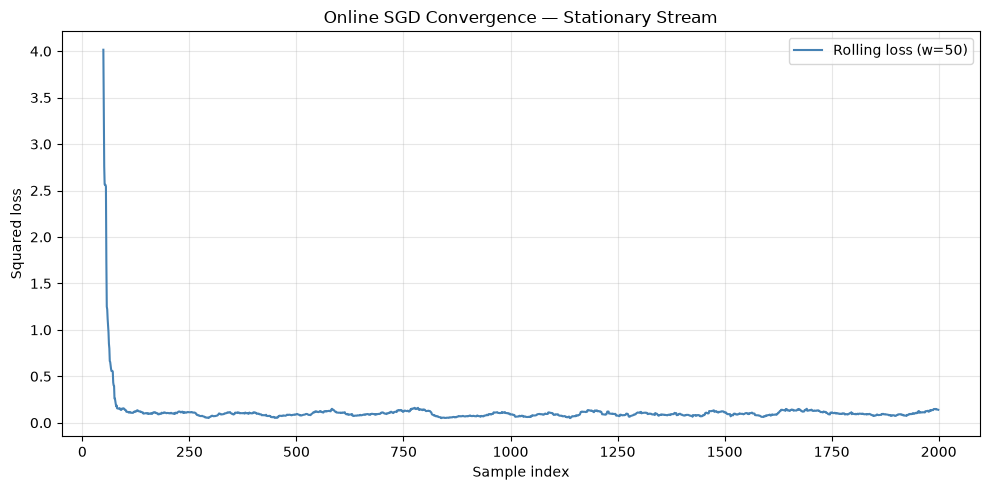

Learned weights: [ 1.464 -2.008  0.545  3.025 -1.026]
True weights:    [ 1.5 -2.   0.5  3.  -1. ]


In [2]:
class OnlineSGDRegressor:
    """Online linear regression via SGD."""
    def __init__(self, n_features, lr=0.01, decay=0.0):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.decay = decay
        self.t = 0
        self.losses = []

    def predict_one(self, x):
        return np.dot(self.w, x) + self.b

    def learn_one(self, x, y):
        self.t += 1
        lr_t = self.lr / (1 + self.decay * self.t)
        yhat = self.predict_one(x)
        error = yhat - y
        self.w -= lr_t * error * x
        self.b -= lr_t * error
        self.losses.append(error ** 2)
        return error ** 2


# Generate a stationary regression stream
n = 2000
X_stream = np.random.randn(n, 5)
true_w = np.array([1.5, -2.0, 0.5, 3.0, -1.0])
y_stream = X_stream @ true_w + 0.3 * np.random.randn(n)

model_online = OnlineSGDRegressor(n_features=5, lr=0.05, decay=0.001)
for xt, yt in zip(X_stream, y_stream):
    model_online.learn_one(xt, yt)

# Smooth losses
window = 50
smooth_losses = pd.Series(model_online.losses).rolling(window).mean()

plt.figure()
plt.plot(smooth_losses, label=f'Rolling loss (w={window})', color='steelblue')
plt.xlabel('Sample index')
plt.ylabel('Squared loss')
plt.title('Online SGD Convergence — Stationary Stream')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Learned weights: {model_online.w.round(3)}')
print(f'True weights:    {true_w}')

---
## 2. Passive-Aggressive Algorithm (PA)

PA updates only when the current prediction is **wrong** (passive when correct, aggressive when wrong).

The update solves:
$$\mathbf{w}_{t+1} = \arg\min_{\mathbf{w}} \frac{1}{2}\|\mathbf{w} - \mathbf{w}_t\|^2 \quad \text{s.t.} \quad \ell(\mathbf{w}; \mathbf{x}_t, y_t) = 0$$

**PA-I** (soft margin, parameter $C$):
$$\mathbf{w}_{t+1} = \mathbf{w}_t + \tau_t y_t \mathbf{x}_t, \quad \tau_t = \min\!\left(C,\, \frac{\ell_t}{\|\mathbf{x}_t\|^2}\right)$$

**PA-II** (quadratic slack):
$$\tau_t = \frac{\ell_t}{\|\mathbf{x}_t\|^2 + \frac{1}{2C}}$$

where $\ell_t = \max(0, 1 - y_t \mathbf{w}_t^\top \mathbf{x}_t)$ is the hinge loss.

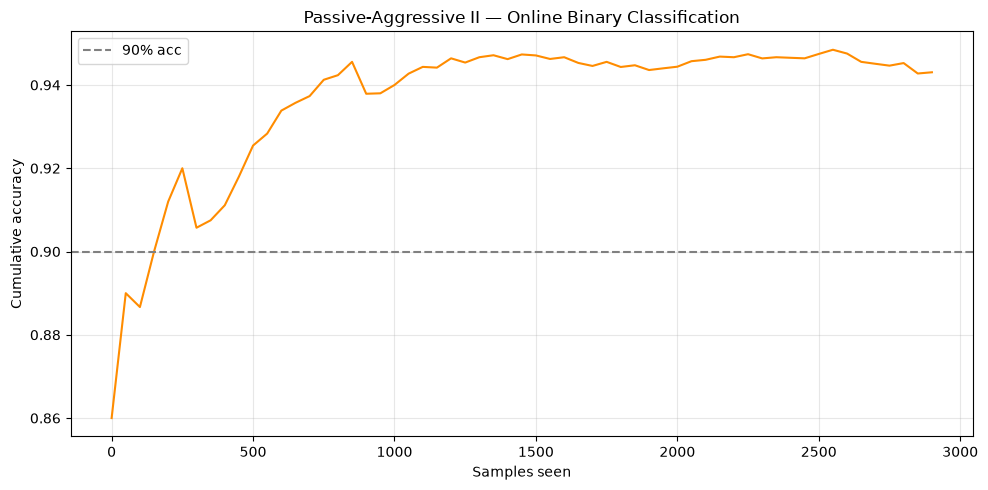

PA-II model updates: 459/3000
Final cumulative accuracy: 0.943


In [3]:
class PassiveAggressiveClassifier:
    def __init__(self, C=1.0, variant='II'):
        self.C = C
        self.variant = variant
        self.w = None
        self.b = 0.0
        self.n_updates = 0

    def _hinge_loss(self, x, y):
        return max(0.0, 1.0 - y * (np.dot(self.w, x) + self.b))

    def predict_one(self, x):
        return np.sign(np.dot(self.w, x) + self.b)

    def learn_one(self, x, y):
        if self.w is None:
            self.w = np.zeros(len(x))
        loss = self._hinge_loss(x, y)
        if loss == 0:
            return  # passive
        norm_sq = np.dot(x, x) + 1e-8
        if self.variant == 'I':
            tau = min(self.C, loss / norm_sq)
        else:  # PA-II
            tau = loss / (norm_sq + 1.0 / (2 * self.C))
        self.w += tau * y * x
        self.b += tau * y
        self.n_updates += 1


# Binary classification stream
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X_clf, y_clf = make_classification(n_samples=3000, n_features=10, random_state=42)
y_clf = np.where(y_clf == 0, -1, 1)  # {-1, +1}
scaler = StandardScaler()
X_clf = scaler.fit_transform(X_clf)

pa_ii = PassiveAggressiveClassifier(C=1.0, variant='II')
rolling_acc = []
correct = 0
for i, (xi, yi) in enumerate(zip(X_clf, y_clf)):
    if pa_ii.w is not None:
        correct += (pa_ii.predict_one(xi) == yi)
    pa_ii.learn_one(xi, yi)
    if i > 0 and i % 50 == 0:
        rolling_acc.append(correct / i)

plt.figure()
plt.plot(np.arange(len(rolling_acc)) * 50, rolling_acc, color='darkorange')
plt.axhline(0.9, ls='--', color='grey', label='90% acc')
plt.xlabel('Samples seen')
plt.ylabel('Cumulative accuracy')
plt.title('Passive-Aggressive II — Online Binary Classification')
plt.legend()
plt.tight_layout()
plt.show()

print(f'PA-II model updates: {pa_ii.n_updates}/{len(y_clf)}')
print(f'Final cumulative accuracy: {rolling_acc[-1]:.3f}')

---
## 3. Concept Drift — Types & Detection

**Concept drift** occurs when the joint distribution $P(X, y)$ changes over time.

| Type | Description | Example |
|------|-------------|----------|
| **Sudden** | Abrupt change at one point | System migration, new regulations |
| **Gradual** | Slow transition between distributions | Seasonal behavior shift |
| **Recurring** | Old distribution returns | Day/night cycles |
| **Incremental** | Continuous slow drift | Customer preference evolution |

**ADWIN** (ADaptive WINdowing): maintains a variable-size sliding window, splits it when the error rate in two halves differs significantly.

$$|\hat{\mu}_0 - \hat{\mu}_1| \geq \epsilon_{\text{cut}}(n_0, n_1, \delta) = \sqrt{\frac{1}{2m^*}\ln\frac{4n}{\delta}}$$

where $m^* = \frac{1}{1/n_0 + 1/n_1}$ is the harmonic mean of subwindow sizes.

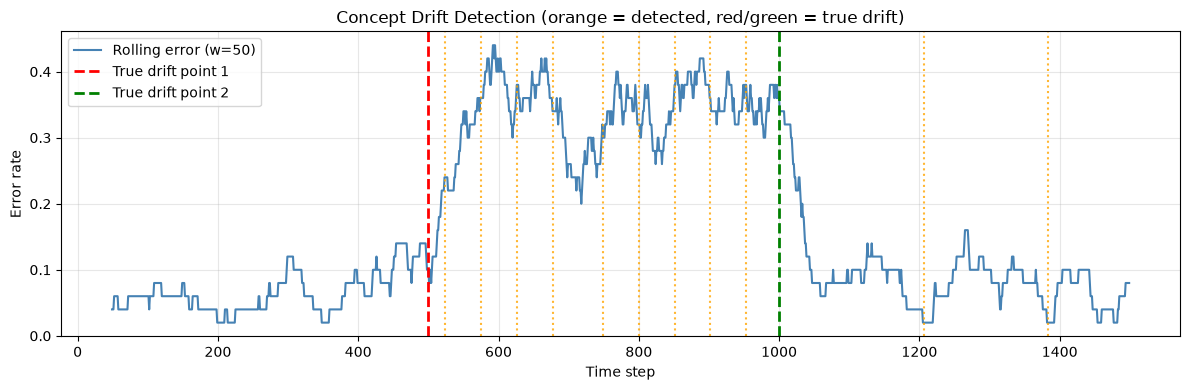

Detected drift at steps: [524, 575, 626, 677, 749, 800, 851, 902, 953, 1206, 1383]


In [4]:
# Simulate sudden concept drift
np.random.seed(0)
n_per_phase = 500
# Phase 1: low error rate ~0.05
stream_phase1 = np.random.binomial(1, 0.05, n_per_phase).astype(float)
# Phase 2: high error rate ~0.35 (sudden drift)
stream_phase2 = np.random.binomial(1, 0.35, n_per_phase).astype(float)
# Phase 3: back to low (recurring)
stream_phase3 = np.random.binomial(1, 0.05, n_per_phase).astype(float)
error_stream = np.concatenate([stream_phase1, stream_phase2, stream_phase3])

# Simple ADWIN-inspired drift detector
def detect_drift_simple(errors, window=100):
    """Simplified drift detection: flag when recent error >> overall mean."""
    drifts = []
    for i in range(window, len(errors)):
        overall_mean = errors[:i].mean()
        recent_mean = errors[i-window//2:i].mean()
        if abs(recent_mean - overall_mean) > 0.15:
            drifts.append(i)
    # Deduplicate nearby detections
    clean = [drifts[0]] if drifts else []
    for d in drifts[1:]:
        if d - clean[-1] > 50:
            clean.append(d)
    return clean

drift_points = detect_drift_simple(error_stream)

rolling_err = pd.Series(error_stream).rolling(50).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_err, color='steelblue', label='Rolling error (w=50)')
ax.axvline(n_per_phase, color='red', ls='--', lw=2, label='True drift point 1')
ax.axvline(2 * n_per_phase, color='green', ls='--', lw=2, label='True drift point 2')
for dp in drift_points:
    ax.axvline(dp, color='orange', ls=':', lw=1.5, alpha=0.8)
ax.set_xlabel('Time step')
ax.set_ylabel('Error rate')
ax.set_title('Concept Drift Detection (orange = detected, red/green = true drift)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Detected drift at steps: {drift_points}')

---
## 4. River Library — Production Online Learning

[River](https://riverml.xyz/) is the standard Python library for online ML. Every model in River exposes:
- `learn_one(x, y)` — update on one sample
- `predict_one(x)` — predict for one sample

where `x` is a **Python dict** `{feature_name: value}`.

River Pipeline (LogisticRegression) final accuracy: 0.9607


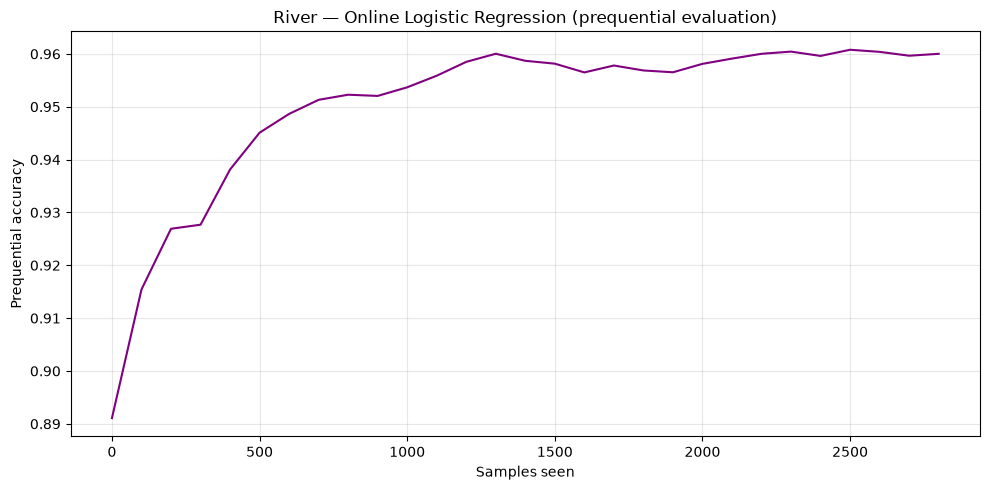

In [5]:
from river import linear_model, preprocessing, metrics, drift, tree, compose, stream

# River pipeline: StandardScaler → LogisticRegression
river_pipeline = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.LogisticRegression(optimizer=None)
)
river_metric = metrics.Accuracy()

# Simulate stream from sklearn dataset
feature_names = [f'f{i}' for i in range(10)]
river_accuracies = []

for i, (xi, yi) in enumerate(zip(X_clf, (y_clf == 1).astype(int))):
    x_dict = dict(zip(feature_names, xi))
    yhat = river_pipeline.predict_one(x_dict)
    river_pipeline.learn_one(x_dict, yi)
    if yhat is not None:
        river_metric.update(yi, yhat)
    if i % 100 == 0 and i > 0:
        river_accuracies.append(river_metric.get())

print(f'River Pipeline (LogisticRegression) final accuracy: {river_metric.get():.4f}')

plt.figure()
plt.plot(np.arange(len(river_accuracies)) * 100, river_accuracies, color='purple')
plt.xlabel('Samples seen')
plt.ylabel('Prequential accuracy')
plt.title('River — Online Logistic Regression (prequential evaluation)')
plt.tight_layout()
plt.show()

Hoeffding Tree final accuracy: 0.9640


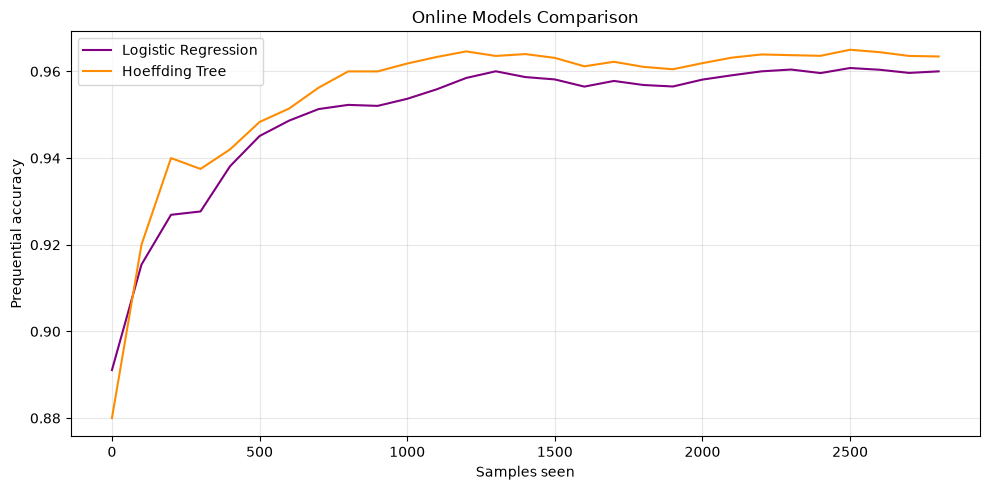

In [6]:
# Hoeffding Tree — online decision tree
from river import tree as river_tree

ht_model = river_tree.HoeffdingTreeClassifier(grace_period=200, max_depth=5)
ht_metric = metrics.Accuracy()
ht_accuracies = []

for i, (xi, yi) in enumerate(zip(X_clf, (y_clf == 1).astype(int))):
    x_dict = dict(zip(feature_names, xi))
    yhat = ht_model.predict_one(x_dict)
    ht_model.learn_one(x_dict, yi)
    if yhat is not None:
        ht_metric.update(yi, yhat)
    if i % 100 == 0 and i > 0:
        ht_accuracies.append(ht_metric.get())

print(f'Hoeffding Tree final accuracy: {ht_metric.get():.4f}')

# Compare both methods
plt.figure()
x_axis = np.arange(len(ht_accuracies)) * 100
plt.plot(x_axis, river_accuracies, label='Logistic Regression', color='purple')
plt.plot(x_axis, ht_accuracies, label='Hoeffding Tree', color='darkorange')
plt.xlabel('Samples seen')
plt.ylabel('Prequential accuracy')
plt.title('Online Models Comparison')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. ADWIN Drift Detector with River

ADWIN detected drift at steps: [575, 1151]
True drift at: 500, 1000


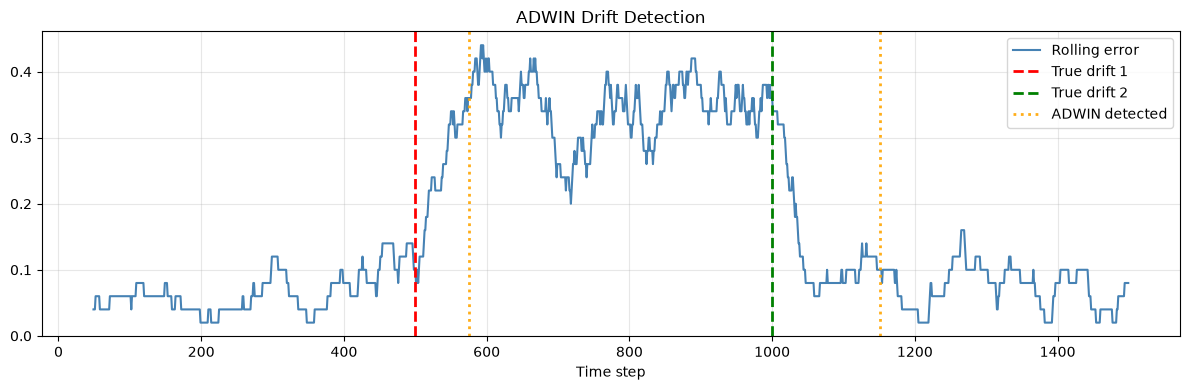

In [7]:
from river.drift import ADWIN

adwin = ADWIN(delta=0.002)
detected = []

for t, err in enumerate(error_stream):
    adwin.update(err)
    if adwin.drift_detected:
        detected.append(t)

print(f'ADWIN detected drift at steps: {detected}')
print(f'True drift at: {n_per_phase}, {2*n_per_phase}')

rolling_err = pd.Series(error_stream).rolling(50).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_err, color='steelblue', label='Rolling error')
ax.axvline(n_per_phase, color='red', ls='--', lw=2, label='True drift 1')
ax.axvline(2 * n_per_phase, color='green', ls='--', lw=2, label='True drift 2')
for d in detected:
    ax.axvline(d, color='orange', ls=':', lw=2, alpha=0.9, label='ADWIN detected' if d == detected[0] else '')
ax.legend()
ax.set_title('ADWIN Drift Detection')
ax.set_xlabel('Time step')
plt.tight_layout()
plt.show()

---
## 6. Practical: Streaming Fraud Detection with Drift

A realistic pipeline: new transactions arrive one at a time. After step 500, fraud patterns change (concept drift). The model with ADWIN resets; the naive model degrades.

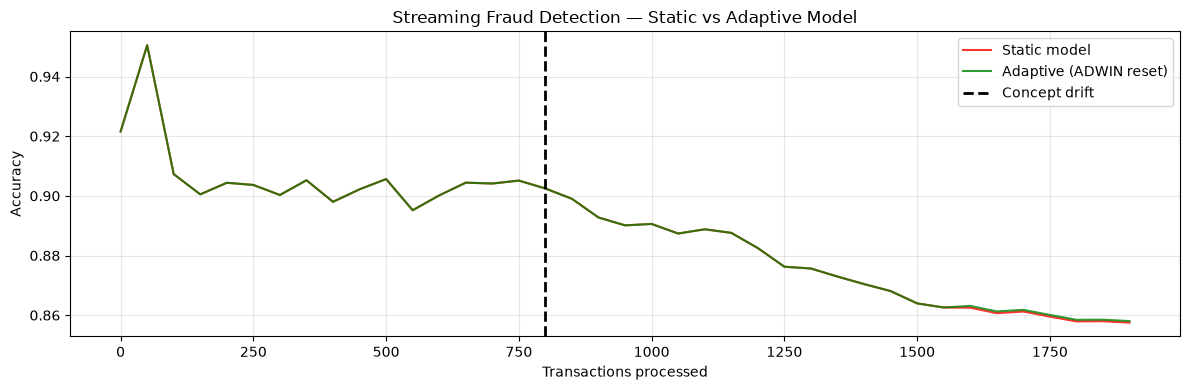

Static model final accuracy:   0.858
Adaptive model final accuracy: 0.858


In [8]:
from river import linear_model, preprocessing, metrics, drift, compose

np.random.seed(7)
N = 2000
DRIFT_AT = 800

# Generate transaction stream with drift
def make_transaction(t, drifted=False):
    if not drifted:
        # Fraud signal: high amount + night hour
        amount = np.random.exponential(100)
        hour = np.random.randint(0, 24)
        is_fraud = int((amount > 200) and (hour < 6))
    else:
        # After drift: fraud switches to daytime small amounts
        amount = np.random.exponential(50)
        hour = np.random.randint(0, 24)
        is_fraud = int((amount < 30) and (hour > 10) and (hour < 18))
    noise = np.random.random() < 0.05
    return {'amount': amount, 'hour': hour, 'n_transactions': np.random.randint(1, 20)}, int(is_fraud ^ noise)

txns = [make_transaction(t, drifted=(t >= DRIFT_AT)) for t in range(N)]

# Model 1: static (no drift adaptation)
model_static = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.LogisticRegression()
)

static_accs, adaptive_accs = [], []
metric_s = metrics.Accuracy()
metric_a = metrics.Accuracy()

adwin2 = ADWIN(delta=0.005)
# Model 2: same but resets on detected drift
model_adaptive = compose.Pipeline(
    preprocessing.StandardScaler(),
    linear_model.LogisticRegression()
)

for i, (x, y) in enumerate(txns):
    yhat_s = model_static.predict_one(x)
    yhat_a = model_adaptive.predict_one(x)

    model_static.learn_one(x, y)
    model_adaptive.learn_one(x, y)

    if yhat_s is not None:
        metric_s.update(y, yhat_s)
    if yhat_a is not None:
        metric_a.update(y, yhat_a)
        adwin2.update(int(yhat_a != y))
        if adwin2.drift_detected:
            # Reset model on detected drift
            model_adaptive = compose.Pipeline(
                preprocessing.StandardScaler(),
                linear_model.LogisticRegression()
            )

    if i % 50 == 0 and i > 0:
        static_accs.append(metric_s.get())
        adaptive_accs.append(metric_a.get())

xs = np.arange(len(static_accs)) * 50
plt.figure(figsize=(12, 4))
plt.plot(xs, static_accs, label='Static model', color='red', alpha=0.8)
plt.plot(xs, adaptive_accs, label='Adaptive (ADWIN reset)', color='green', alpha=0.8)
plt.axvline(DRIFT_AT, color='black', ls='--', lw=2, label='Concept drift')
plt.xlabel('Transactions processed')
plt.ylabel('Accuracy')
plt.title('Streaming Fraud Detection — Static vs Adaptive Model')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Static model final accuracy:   {static_accs[-1]:.3f}')
print(f'Adaptive model final accuracy: {adaptive_accs[-1]:.3f}')

---
## 7. Online vs Batch SGD — Convergence Comparison

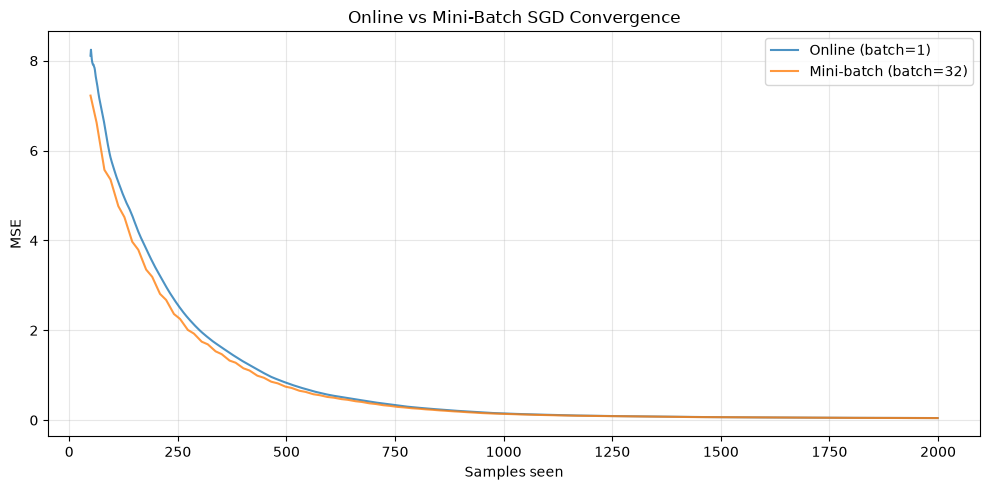

In [9]:
from sklearn.linear_model import SGDRegressor

# Compare online SGD (one sample at a time) vs mini-batch SGD
n_train = 2000
X_reg = np.random.randn(n_train, 8)
true_coef = np.array([2, -1, 0.5, 1.5, -2, 0, 0.8, -0.3])
y_reg = X_reg @ true_coef + 0.2 * np.random.randn(n_train)

# Online: process 1 sample at a time
online_sgd = SGDRegressor(eta0=0.01, learning_rate='invscaling', max_iter=1, tol=None, warm_start=True)
online_losses = []
for i in range(1, n_train + 1):
    online_sgd.partial_fit(X_reg[i-1:i], y_reg[i-1:i])
    pred = online_sgd.predict(X_reg[:i])
    online_losses.append(np.mean((pred - y_reg[:i])**2))

# Mini-batch: process 32 samples at a time
batch_sgd = SGDRegressor(eta0=0.01, learning_rate='invscaling', max_iter=1, tol=None, warm_start=True)
batch_losses = []
batch_size = 32
for i in range(0, n_train, batch_size):
    batch_sgd.partial_fit(X_reg[i:i+batch_size], y_reg[i:i+batch_size])
    pred = batch_sgd.predict(X_reg[:i+batch_size])
    for _ in range(batch_size):
        batch_losses.append(np.mean((pred - y_reg[:i+batch_size])**2))

batch_losses = batch_losses[:n_train]

plt.figure()
plt.plot(pd.Series(online_losses).rolling(50).mean(), label='Online (batch=1)', alpha=0.8)
plt.plot(pd.Series(batch_losses).rolling(50).mean(), label='Mini-batch (batch=32)', alpha=0.8)
plt.xlabel('Samples seen')
plt.ylabel('MSE')
plt.title('Online vs Mini-Batch SGD Convergence')
plt.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Algorithm | Update Rule | Best For |
|-----------|-------------|----------|
| **Online SGD** | $\mathbf{w} -= \eta \nabla \ell$ per sample | Regression, large-scale classification |
| **Passive-Aggressive** | Update only on violation, size $\propto$ loss | Low-noise streams, classification |
| **FTRL** | Penalised cumulative loss minimisation | Ad-click prediction, sparse features |
| **Hoeffding Tree** | Split test based on Hoeffding bound | Streaming classification, explainability |
| **ADWIN** | Adaptive window drift detection | Any stream where distribution changes |

**Key takeaway**: For production streaming systems, always pair an online model with a drift detector. Without drift detection, model accuracy degrades silently after distribution shift.

---
## Additional Learning Resources

- **River Documentation** — https://riverml.xyz/latest/ — Complete online ML library reference
- **Cesa-Bianchi & Lugosi (2006)** — *Prediction, Learning, and Games* — The textbook on online learning theory
- **Gama et al. (2014)** — *A Survey on Concept Drift Adaptation* — ACM Computing Surveys, comprehensive drift taxonomy
- **Bifet & Gavaldà (2007)** — *Learning from Time-Changing Data with Adaptive Windowing (ADWIN)* — Original ADWIN paper
- **Crammer et al. (2006)** — *Online Passive-Aggressive Algorithms* — JMLR, PA derivation and proofs
- **McMahan et al. (2013)** — *Ad Click Prediction: a View from the Trenches* — Google's FTRL at scale (KDD 2013)
- **Hulten et al. (2001)** — *Mining Time-Changing Data Streams* — Original Hoeffding Tree paper